In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Load model
with open("/content/drive/MyDrive/FactLens_Group9/data/logistic_regression_model.pkl", "rb") as f:
    model = pickle.load(f)

# Load test set
X_test = sp.load_npz("/content/drive/MyDrive/FactLens_Group9/data/X_test.npz")
y_test = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/y_test.csv")["label"]

print(f"Model loaded successfully")
print(f"Test matrix loaded: {X_test.shape}")
print(f"Test labels loaded: {len(y_test)}")
print(f"\nTest label distribution:")
print(y_test.value_counts())

Model loaded successfully
Test matrix loaded: (7718, 50000)
Test labels loaded: 7718

Test label distribution:
label
REAL    4238
FAKE    3480
Name: count, dtype: int64


In [4]:
# Generate predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("Predictions generated successfully")
print(f"Total predictions: {len(y_pred)}")
print(f"\nPredicted label distribution:")
print(pd.Series(y_pred).value_counts())

Predictions generated successfully
Total predictions: 7718

Predicted label distribution:
REAL    4270
FAKE    3448
Name: count, dtype: int64


In [6]:
# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy:.2%})")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Overall Accuracy: 0.9852 (98.52%)

Detailed Classification Report:
              precision    recall  f1-score   support

        FAKE       0.99      0.98      0.98      3480
        REAL       0.98      0.99      0.99      4238

    accuracy                           0.99      7718
   macro avg       0.99      0.98      0.99      7718
weighted avg       0.99      0.99      0.99      7718



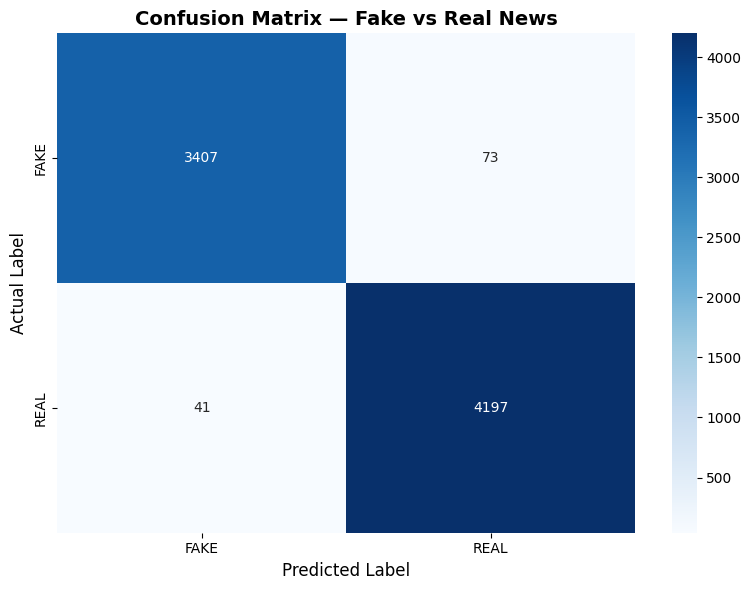


Breakdown:
  Correctly identified FAKE articles:           4,197
  Correctly identified REAL articles:           3,407
  FAKE articles incorrectly called REAL (missed): 41
  REAL articles incorrectly called FAKE:          73


In [7]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["FAKE", "REAL"])

# Plot it
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["FAKE", "REAL"],
            yticklabels=["FAKE", "REAL"])
plt.title("Confusion Matrix — Fake vs Real News", fontsize=14, fontweight="bold")
plt.ylabel("Actual Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/confusion_matrix.png", dpi=150)
plt.show()

# Print readable breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nBreakdown:")
print(f"  Correctly identified FAKE articles:           {tp:,}")
print(f"  Correctly identified REAL articles:           {tn:,}")
print(f"  FAKE articles incorrectly called REAL (missed): {fn:,}")
print(f"  REAL articles incorrectly called FAKE:          {fp:,}")

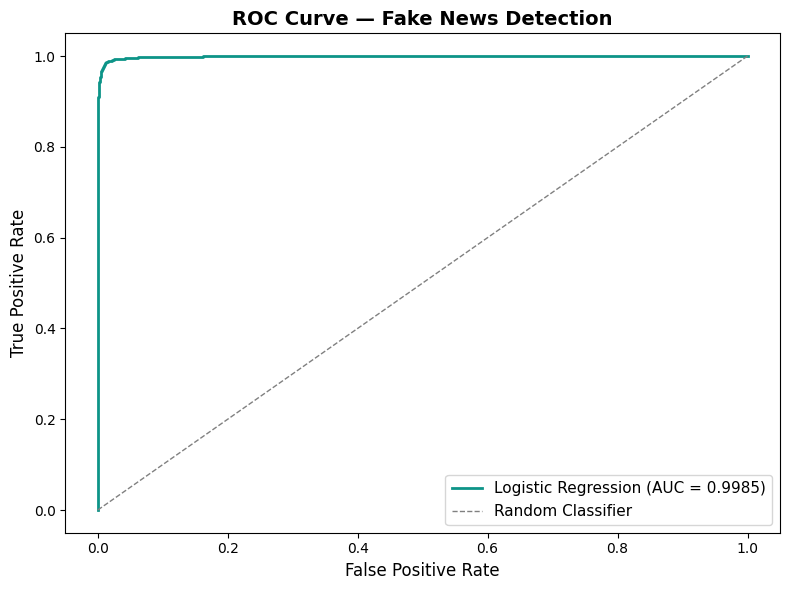

AUC Score: 0.9985


In [8]:
# Convert labels to binary for ROC curve
y_test_binary = (y_test == "FAKE").astype(int)
y_prob_fake = y_prob[:, 0]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_fake)
auc_score = roc_auc_score(y_test_binary, y_prob_fake)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#0D9488", linewidth=2,
         label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linewidth=1,
         linestyle="--", label="Random Classifier")
plt.title("ROC Curve — Fake News Detection", fontsize=14, fontweight="bold")
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FactLens_Group9/data/roc_curve.png", dpi=150)
plt.show()

print(f"AUC Score: {auc_score:.4f}")

In [9]:
# Load training data to check for overfitting
X_train = sp.load_npz("/content/drive/MyDrive/FactLens_Group9/data/X_train.npz")
y_train = pd.read_csv("/content/drive/MyDrive/FactLens_Group9/data/y_train.csv")["label"]

train_accuracy = accuracy_score(y_train, model.predict(X_train))
test_accuracy = accuracy_score(y_test, y_pred)
gap = train_accuracy - test_accuracy

print("Overfitting Check:")
print(f"  Training accuracy: {train_accuracy:.4f} ({train_accuracy:.2%})")
print(f"  Test accuracy:     {test_accuracy:.4f} ({test_accuracy:.2%})")
print(f"  Gap:               {gap:.4f} ({gap:.2%})")

if gap < 0.05:
    print("\n  ✓ Gap is small — no significant overfitting detected")
elif gap < 0.10:
    print("\n  ⚠ Moderate gap — minor overfitting present")
else:
    print("\n  ✗ Large gap — significant overfitting detected")

Overfitting Check:
  Training accuracy: 0.9921 (99.21%)
  Test accuracy:     0.9852 (98.52%)
  Gap:               0.0068 (0.68%)

  ✓ Gap is small — no significant overfitting detected


In [10]:
print("=" * 55)
print("EVALUATION SUMMARY — FAKE VS REAL NEWS CLASSIFIER")
print("=" * 55)
print(f"Total test articles:      {len(y_test):,}")
print(f"Overall accuracy:         {accuracy:.2%}")
print(f"AUC Score:                {auc_score:.4f}")
print(f"Training accuracy:        {train_accuracy:.2%}")
print(f"Test accuracy:            {test_accuracy:.2%}")
print(f"Overfitting gap:          {gap:.2%}")
print(f"Correctly identified:     {(y_pred == y_test).sum():,} out of {len(y_test):,}")
print(f"Misclassified:            {(y_pred != y_test).sum():,} out of {len(y_test):,}")
print("=" * 55)

EVALUATION SUMMARY — FAKE VS REAL NEWS CLASSIFIER
Total test articles:      7,718
Overall accuracy:         98.52%
AUC Score:                0.9985
Training accuracy:        99.21%
Test accuracy:            98.52%
Overfitting gap:          0.68%
Correctly identified:     7,604 out of 7,718
Misclassified:            114 out of 7,718
